## Project Workflow

- Data Loading & Understanding
- Data Cleaning
- Exploratory Data Analysis(EDA)
- Data Preprocessing
- Feature Scalling
- Train-Test-Split
- Model Building
- Model Evaluation
- Handling Class Imblance(SMOTE)
- Hyperparameter Tuning
- Feature Importance Analysis
- Conclusion

In [184]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import xgboost
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv(r"C:\Users\user\Downloads\creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.shape

(284807, 31)

In [4]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
df.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Columns are well filled, no empty rows/cells

In [7]:
df.duplicated().sum()

np.int64(1081)

In [10]:
##Checking the default class

df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [11]:
df["Class"].value_counts(normalize=True)*100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

Class is highly in-balanced, we would address that later

In [15]:
##investigating the duplicates values found earlier 

df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(20)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
34,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
32,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
112,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
220,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,1.213826,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0
221,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,1.213826,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0


They appear to be true duplicates so lets handle them

In [17]:
#Count duplicates rows 

duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

#Shape before removing duplicates 
print("Shape Before:", df.shape)

Duplicate rows: 1081
Shape Before: (284807, 31)


In [18]:
#Dropping the duplicates 

df = df.drop_duplicates()

print("Shape After:", df.shape)

Shape After: (283726, 31)


In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.dtypes.value_counts()

float64    30
int64       1
Name: count, dtype: int64

In [21]:
df.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

In [22]:
df.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [25]:
#Checking the target variable again

class_count = df["Class"].value_counts()

class_count

Class
0    283253
1       473
Name: count, dtype: int64

In [27]:
class_percent = df["Class"].value_counts(normalize=True)*100

class_percent

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

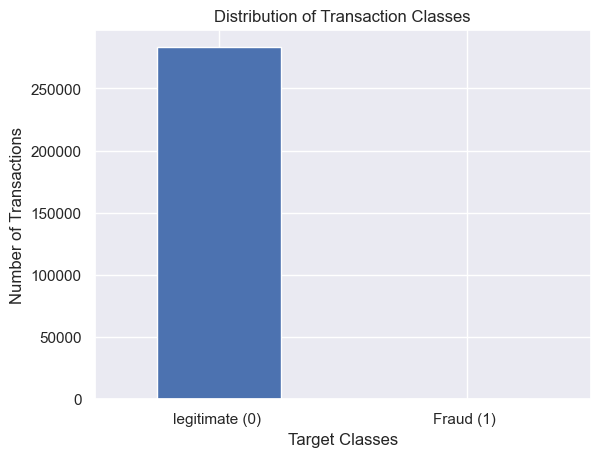

In [36]:
class_count.plot(kind="bar")

plt.title("Distribution of Transaction Classes")
plt.xlabel("Target Classes")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ["legitimate (0) ", "Fraud (1) "], rotation=0)

plt.show()

In [32]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,283726.0,94811.077600,47481.047891,0.000000,54204.750000,84692.500000,139298.000000,172792.000000
V1,283726.0,0.005917,1.948026,-56.407510,-0.915951,0.020384,1.316068,2.454930
V2,283726.0,-0.004135,1.646703,-72.715728,-0.600321,0.063949,0.800283,22.057729
V3,283726.0,0.001613,1.508682,-48.325589,-0.889682,0.179963,1.026960,9.382558
V4,283726.0,-0.002966,1.414184,-5.683171,-0.850134,-0.022248,0.739647,16.875344
V5,283726.0,0.001828,1.377008,-113.743307,-0.689830,-0.053468,0.612218,34.801666
V6,283726.0,-0.001139,1.331931,-26.160506,-0.769031,-0.275168,0.396792,73.301626
V7,283726.0,0.001801,1.227664,-43.557242,-0.552509,0.040859,0.570474,120.589494
V8,283726.0,-0.000854,1.179054,-73.216718,-0.208828,0.021898,0.325704,20.007208
V9,283726.0,-0.001596,1.095492,-13.434066,-0.644221,-0.052596,0.595977,15.594995


In [33]:
df["Amount"].describe()

count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64

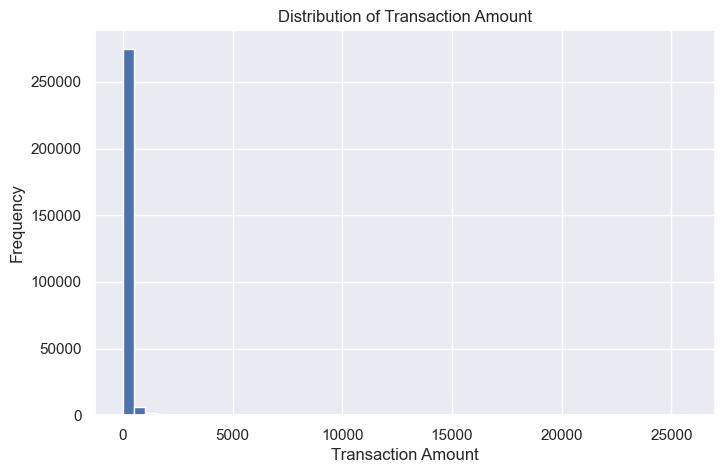

In [39]:
plt.figure(figsize=(8, 5))

plt.hist(df["Amount"], bins=50)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

In [40]:
##Lets check the target variable and the amount

df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


In [41]:
#Checking whether there are impossible values in the time and amount column. lets check the minimum and maximum

df[["Time","Amount"]].min()

Time      0.0
Amount    0.0
dtype: float64

This is okay, there are no negatives

In [42]:
df[["Time","Amount"]].max()

Time      172792.00
Amount     25691.16
dtype: float64

In [43]:
(df["Amount"] < 0).sum()

np.int64(0)

## Feature Preprocessing

In [44]:
#Seperating the feactures from the target variables

x = df.drop(columns= "Class", axis=1)
y= df["Class"]

x.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99


In [45]:
print("Features shape:", x.shape)
print("Target Variable:", y.shape)

Features shape: (283726, 30)
Target Variable: (283726,)


## Feature Scalling

We are scaling because some of the values in the time and amount column may be too far from the other columns

In [49]:
##Lets create an instance for the scalling 

scaler = StandardScaler()

scaledx = scaler.fit_transform(x)

In [50]:
scaledx

array([[-1.99682292, -0.70108232, -0.04168726, ...,  0.33303251,
        -0.06584955,  0.24419951],
       [-1.99682292,  0.60879165,  0.16413764, ..., -0.0271543 ,
         0.0432187 , -0.34258399],
       [-1.99680186, -0.7003364 , -0.81133678, ..., -0.14432548,
        -0.18382429,  1.15889967],
       ...,
       [ 1.64227757,  0.98235398, -0.18043304, ...,  0.00680174,
        -0.08264021, -0.0822395 ],
       [ 1.64227757, -0.12646526,  0.32465977, ...,  0.27052318,
         0.31700384, -0.31339058],
       [ 1.64236181, -0.27686005, -0.1127094 , ..., -0.01055821,
         0.03994074,  0.51329005]], shape=(283726, 30))

In [51]:
y

0         0
1         0
2         0
3         0
4         0
         ..
284802    0
284803    0
284804    0
284805    0
284806    0
Name: Class, Length: 283726, dtype: int64

## Train-Test Split

We would be using the 80:20 ratio for training and test data set

In [52]:
X_train, X_test, y_train, y_test = train_test_split(scaledx, y, test_size=0.2, random_state=42, stratify=y)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_train:", y_test.shape) 

X_train: (226980, 30)
X_test: (56746, 30)
y_train: (226980,)
y_train: (56746,)


**Note:** from the EDA and Data Cleaning i notice that the target class is imbalanced. Using stratify here ensure that the train and test sets have approximately the same proportion of default and non default cases. This ensures accurate training of the model and more reliable performance metrics.

## Model Building

### 1. Logistic Regeression

In [53]:
##Creating an instance 
log = LogisticRegression()

log.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [54]:
### Model Prediction 

log_pred = log.predict(X_test)

### Metrics for Classification Models

we would be using metrics such as accuracy_score, classification_report, confusion_matrix to evaluate the models

In [57]:
##Accuracy score
accuracy_score(y_test, log_pred)

0.9991365030134283

In [59]:
## Classification_report

print(classification_report(y_test, log_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.59      0.70        95

    accuracy                           1.00     56746
   macro avg       0.92      0.79      0.85     56746
weighted avg       1.00      1.00      1.00     56746



In [61]:
##Confusion Matrix

cm = confusion_matrix(y_test, log_pred)

cm

array([[56641,    10],
       [   39,    56]])

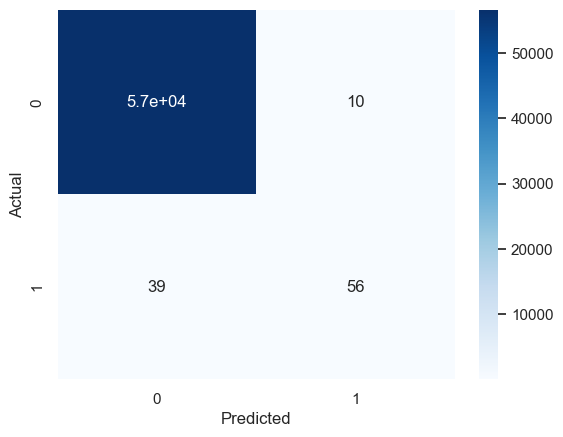

In [62]:
##Lets display this on a heatmap

sns.heatmap(cm, annot=True, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

True Negative - 56641 (The number of non fraudulent transactions the model rightly predicted) i.e the actual negative predicted to be negative

False Positive- 10 (The number of non-fraudulent transactions the model predicted as defaulted) i.e actual negative predicted to be fraudulent

True Positive- 56 (The number of fraudulent transaction the model predicted rightly i.e as fraudulent)

False Negative- 39 (The number of fraudulent transactions the model predicted as non fraudulent)

### ROC-AUC Scores

This measures how well the model can distinguish between the two classes

In [65]:
log_probs = log.predict_proba(X_test)[:, 1]

log_probs

array([2.63227534e-04, 2.99012352e-04, 2.47219155e-05, ...,
       3.24008095e-04, 1.66417598e-04, 3.72607465e-05], shape=(56746,))

In [66]:
## Roc-Auc Scores

auc_score = roc_auc_score(y_test, log_probs)

auc_score

0.9548900051933863

In [67]:
##plotting the curve; fpr is false positive rate and tpr; true positive rate. if the curve is closer to right angle, the classifier is okay

fpr, tpr, threshold = roc_curve(y_test, log_probs)

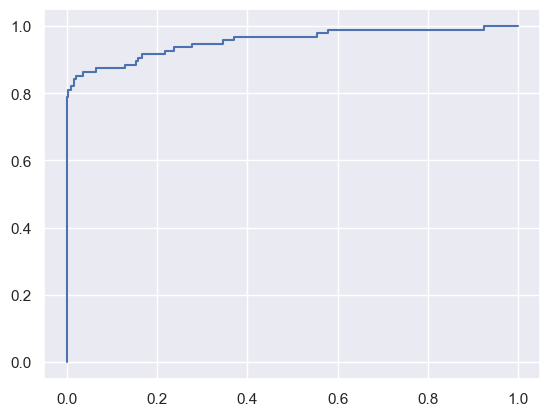

In [68]:
plt.plot(fpr, tpr)

plt.show()

## 2. Random Forest

In [71]:
##Creating an instance 
rf = RandomForestClassifier(random_state=10)

rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [72]:
rf_pred = rf.predict(X_test)

In [74]:
accuracy_score(y_test, rf_pred)

0.9995594403129736

In [75]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.99      0.75      0.85        95

    accuracy                           1.00     56746
   macro avg       0.99      0.87      0.93     56746
weighted avg       1.00      1.00      1.00     56746



In [76]:
##Confusion Matrix

cm = confusion_matrix(y_test, rf_pred)

cm

array([[56650,     1],
       [   24,    71]])

In [77]:
### ROC-AUC Scores

rf_probs = rf.predict_proba(X_test)[:, 1]

In [78]:
auc_score = roc_auc_score(y_test, rf_probs)

auc_score

0.9242624044356536

In [79]:
fpr, tpr, threshold = roc_curve(y_test, rf_probs)

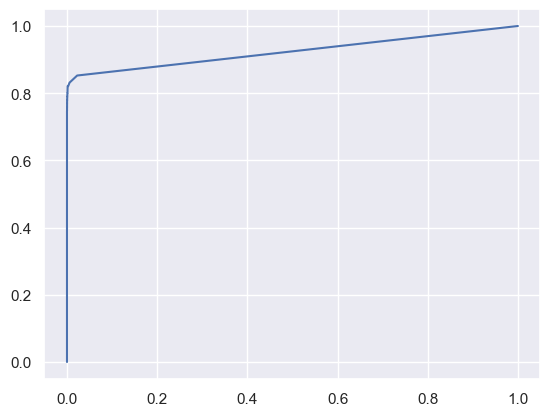

In [80]:
plt.plot(fpr, tpr)

plt.show()

## 3. Gradient Boost

In [82]:
##Creating an instance 

gradient_boost = GradientBoostingClassifier(random_state=10)

gradient_boost.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [83]:
#Prediction

gb_pred = gradient_boost.predict(X_test)

In [84]:
accuracy_score(y_test, gb_pred)

0.9992422373383146

In [86]:
print(classification_report(y_test, gb_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.87      0.64      0.74        95

    accuracy                           1.00     56746
   macro avg       0.94      0.82      0.87     56746
weighted avg       1.00      1.00      1.00     56746



In [87]:
##Confusion Matrix

cm = confusion_matrix(y_test, gb_pred)

cm

array([[56642,     9],
       [   34,    61]])

In [105]:
### ROC-AUC Scores

gb_probs = gradient_boost.predict_proba(X_test)[:, 1]

In [106]:
auc_score = roc_auc_score(y_test, gb_probs)

auc_score

0.8434128073179364

In [107]:
fpr, tpr, threshold = roc_curve(y_test, gb_probs)

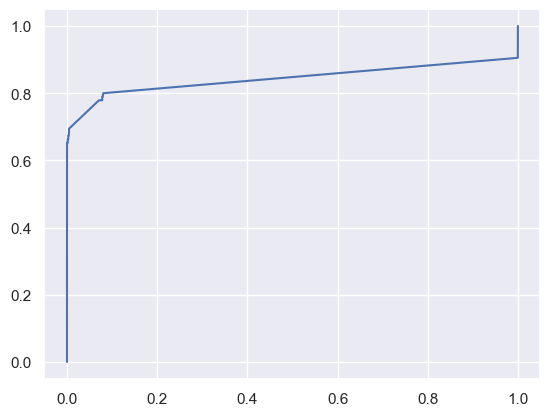

In [108]:
plt.plot(fpr, tpr)

plt.show()

In [109]:
results = {"Models":["Logistic Regression", "Random Forest", "Gradient Boosting"], 
             "Accuracy":[0.99,0.99,0.99], "Precision(Default)":[0.85,0.99,0.87], 
             "Recall(Default)":[0.59,0.75,0.64], "F1(Default)":[0.70,0.85,0.74],
           "ROC_AUC":[0.95,0.92,0.84]}

model_summary = pd.DataFrame(results)

model_summary

,Models,Accuracy,Precision(Default),Recall(Default),F1(Default),ROC_AUC
0,Logistic Regression,0.99,0.85,0.59,0.70,0.95
1,Random Forest,0.99,0.99,0.75,0.85,0.92
2,Gradient Boosting,0.99,0.87,0.64,0.74,0.84


## Model Improvement Technique
Using theSynthetic Minority Over-Sampling Technique (SMOTE) to balance the training data. 

### Handling the class imbalance with SMOTE

Why are we using this?

Because our target distribution is approximately 99% not fraudulent and 0.17% fraudulent i.e imbalanced 

In [110]:
##lets verify the original class distribution

y_train.value_counts(normalize=True) * 100

Class
0    99.833466
1     0.166534
Name: proportion, dtype: float64

In [111]:
##applying SMOTE

#creating an instance
smote = SMOTE(random_state=10)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [112]:
##Now lets verify the new classes

y_train_smote.value_counts()

Class
0    226602
1    226602
Name: count, dtype: int64

In [113]:
##Now lets verify the new classes

y_train_smote.value_counts(normalize=True) * 100

Class
0    50.0
1    50.0
Name: proportion, dtype: float64

Now the class is balanced, lets retrain our classification models

## Training the Models after SMOTE

### 1. Logistic Regression

In [114]:
##Creating an instance 

lr_smote = LogisticRegression()

lr_smote.fit(X_train_smote, y_train_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [115]:
#Prediction

lr_smote_pred = lr_smote.predict(X_test)

In [116]:
##Accuracy Score

accuracy_score(y_test, lr_smote_pred)

0.9733549501286435

In [117]:
##Classification report

print(classification_report(y_test, lr_smote_pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.98     56746



In [118]:
##Confusion matrixs

cm = confusion_matrix(y_test, lr_smote_pred)

cm

array([[55151,  1500],
       [   12,    83]])

In [119]:
 ### ROC-AUC Scores

lr_smote_probs = lr_smote.predict_proba(X_test)[:, 1]

In [120]:
auc_score = roc_auc_score(y_test, lr_smote_probs)

auc_score

0.9633389664696772

In [123]:
fpr, tpr, threshold = roc_curve(y_test, lr_smote_probs)

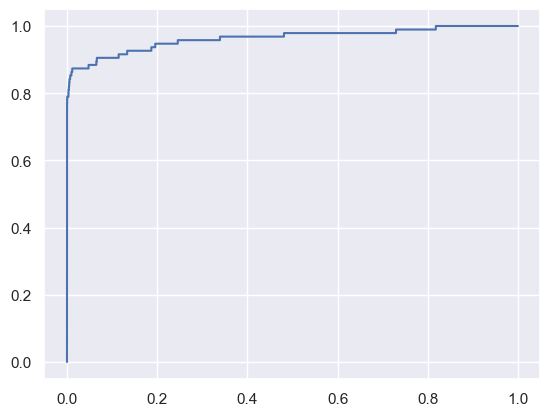

In [124]:
plt.plot(fpr, tpr)

plt.show()

## 2. Random Forest

In [125]:
##Creating an instance

rf_smote = RandomForestClassifier(random_state=10)

rf_smote.fit(X_train_smote, y_train_smote)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [126]:
##model prediction

rf_smote_pred = rf_smote.predict(X_test)

In [127]:
##accuracy_score

accuracy_score(y_test, rf_smote_pred)

0.9994360836006062

In [129]:
##Classification Report

print(classification_report(y_test, rf_smote_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.91      0.74      0.81        95

    accuracy                           1.00     56746
   macro avg       0.95      0.87      0.91     56746
weighted avg       1.00      1.00      1.00     56746



In [130]:
##Confusion matrix

cm = confusion_matrix(y_test, rf_smote_pred)

cm

array([[56644,     7],
       [   25,    70]])

In [131]:
rf_smote_probs = rf_smote.predict_proba(X_test)[:,1]

In [132]:
auc_score = roc_auc_score(y_test, rf_smote_probs)

auc_score

0.9648299978910577

In [133]:
fpr, tpr, threshold = roc_curve(y_test, rf_smote_probs)

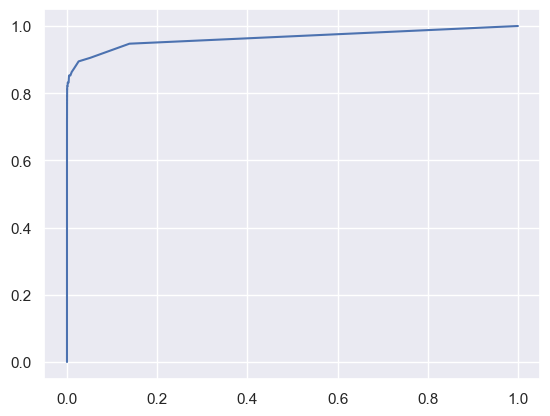

In [134]:
plt.plot(fpr, tpr)

plt.show()

## 3. Gradient Boosting

In [135]:
#Creating an instance 

gb_smote = GradientBoostingClassifier(random_state=10)

#lets fit
gb_smote.fit(X_train_smote, y_train_smote)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [136]:
##prediction

gb_smote_pred = gb_smote.predict(X_test)

In [137]:
##Accuracy

accuracy_score(y_test, gb_smote_pred)

0.9888978958869348

In [138]:
print(classification_report(y_test, gb_smote_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56651
           1       0.12      0.85      0.20        95

    accuracy                           0.99     56746
   macro avg       0.56      0.92      0.60     56746
weighted avg       1.00      0.99      0.99     56746



In [139]:
##Confusion matrix

cm = confusion_matrix(y_test, gb_smote_pred)

cm

array([[56035,   616],
       [   14,    81]])

In [140]:
gb_smote_probs = gb_smote.predict_proba(X_test)[:,1]

In [142]:
auc_score = roc_auc_score(y_test, gb_smote_probs)

auc_score

0.9765120511646099

In [143]:
##lets get the curve

fpr, tpr, threshold = roc_curve(y_test, gb_smote_probs)

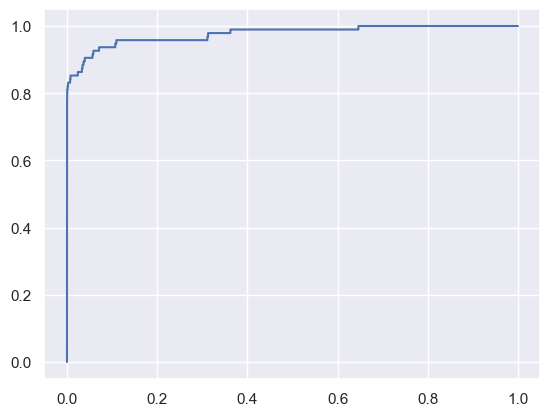

In [144]:
##plotting the curve

plt.plot(fpr,tpr)

plt.show()

In [145]:
compare = {"Models":["Logistic Regression", "Random Forest", "Gradient Boosting","Logistic Regression(SMOTE)","Random Forest(SMOTE)","Gradient Boosting(SMOTE)"], 
             "Accuracy":[0.99,0.99,0.99,0.97,0.99,0.98], "Precision(Default)":[0.85,0.99,0.87,0.05,0.91,0.12], 
             "Recall(Default)":[0.59,0.75,0.64,0.87,0.74,0.85], "F1(Default)":[0.70,0.85,0.74,0.10,0.81,0.20],
           "ROC_AUC":[0.95,0.92,0.84,0.96,0.96,0.97]}

model_summary1 = pd.DataFrame(compare)

model_summary1

,Models,Accuracy,Precision(Default),Recall(Default),F1(Default),ROC_AUC
0,Logistic Regression,0.99,0.85,0.59,0.70,0.95
1,Random Forest,0.99,0.99,0.75,0.85,0.92
2,Gradient Boosting,0.99,0.87,0.64,0.74,0.84
3,Logistic Regression(SMOTE),0.97,0.05,0.87,0.10,0.96
4,Random Forest(SMOTE),0.99,0.91,0.74,0.81,0.96
5,Gradient Boosting(SMOTE),0.98,0.12,0.85,0.20,0.97


## Summary
Random Forest with SMOTE is currently the strongest model because it provides the best balance between precision, recall, F1-score and ROC-AUC among the SMOTE-trained models. While Gradient Boosting with SMOTE achieved the highest recall (0.85) and ROC-AUC (0.97), its very low precision (0.12) indicates a high rate of false positives. Logistic Regression with SMOTE similarly achieved high recall (0.87) but extremely low precision (0.05). Random Forest with SMOTE achieved a much stronger balance, with 0.91 precision, 0.74 recall, 0.81 F1-score and 0.96 ROC-AUC.

## Hyperparameter Tunning of the SMOTEC(Models)

To tune this models, the SMOTE would be applied inside the cross-validation pipeline, so each cv training fold gets its own synthetic observation. This ensures that there are no data leakages.

### 1. Logistic Regression(SMOTE) 

In [146]:
##getting parameters

lr_smote.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [148]:
#building the pipeline

lr_pipeline = Pipeline([("smote",SMOTE(random_state=10)),("model", LogisticRegression(max_iter=1000, random_state=10))])

In [149]:
lr_params = {"smote__sampling_strategy": [0.3, 0.5, 0.7, 1.0],"model__C": [0.01, 0.1, 1, 10, 100],
             "model__solver": ["liblinear", "lbfgs"]}

In [150]:
#Now lets tune using randomized search cv
lr_search = RandomizedSearchCV(estimator=lr_pipeline,param_distributions=lr_params, n_iter=10, scoring="roc_auc", cv=3, random_state=10, 
                               n_jobs=-1, verbose=1)

In [151]:
##Lets fit but this time we would fit to the original training dataset since smote is applied in the pipeline

lr_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,estimator,Pipeline(step...m_state=10))])
,param_distributions,"{'model__C': [0.01, 0.1, ...], 'model__solver': ['liblinear', 'lbfgs'], 'smote__sampling_strategy': [0.3, 0.5, ...]}"
,n_iter,10
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,10
,error_score,nan


In [152]:
##Best Parameters

print("Best parameters:")
print(lr_search.best_params_)

Best parameters:
{'smote__sampling_strategy': 0.7, 'model__solver': 'liblinear', 'model__C': 0.01}


In [155]:
lr_tuned = lr_search.best_estimator_

lr_pred = lr_tuned.predict(X_test)
lr_prob = lr_tuned.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, lr_pred))


Accuracy: 0.9821132767067282


In [156]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.08      0.87      0.14        95

    accuracy                           0.98     56746
   macro avg       0.54      0.93      0.57     56746
weighted avg       1.00      0.98      0.99     56746



In [157]:
print("ROC-AUC:", roc_auc_score(y_test, lr_prob))

ROC-AUC: 0.9642032611492899


### 2. Random Forest(SMOTE)

In [159]:
##creating the pipeline

rf_pipeline = Pipeline([("smote",SMOTE(random_state=10)),("model", RandomForestClassifier(random_state=10, n_jobs=1))])

In [160]:
#defining the parameters
rf_params = {"smote__sampling_strategy": [0.3, 0.5, 0.7, 1.0],"model__n_estimators": [100, 200],"model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],"model__min_samples_leaf": [1, 2], "model__max_features": ['sqrt', 'log2']}

In [163]:
rf_search = RandomizedSearchCV(estimator=rf_pipeline, param_distributions=rf_params, n_iter=10, scoring='roc_auc', cv=3,
    random_state=42, n_jobs=-1, verbose=1)

In [164]:
#lets fit

rf_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,estimator,Pipeline(step...m_state=10))])
,param_distributions,"{'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], ...}"
,n_iter,10
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [167]:
print("Best parameters:")
print(rf_search.best_params_)

print("\nBest CV ROC-AUC:")
print(rf_search.best_score_)

Best parameters:
{'smote__sampling_strategy': 0.3, 'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 10}

Best CV ROC-AUC:
0.9831604969092723


In [168]:
rf_tuned = rf_search.best_estimator_

rf_pred = rf_tuned.predict(X_test)
rf_prob = rf_tuned.predict_proba(X_test)[:, 1]

In [169]:
print("Accuracy:", accuracy_score(y_test, rf_pred))

Accuracy: 0.9992246149508336


In [170]:
print(classification_report(y_test, rf_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.76      0.78      0.77        95

    accuracy                           1.00     56746
   macro avg       0.88      0.89      0.89     56746
weighted avg       1.00      1.00      1.00     56746



In [183]:
cm = confusion_matrix(y_test, rf_pred)

cm

array([[56628,    23],
       [   21,    74]])

In [171]:
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

ROC-AUC: 0.9799481404611244


### 3. Gradient Boosting

In [173]:
gb_pipeline = Pipeline([("smote", SMOTE(random_state=10)), ("model", GradientBoostingClassifier(random_state=10))])

In [174]:
## Defining the parameters

gb_params = {"smote__sampling_strategy": [0.3, 0.5, 0.7, 1.0],"model__n_estimators": [50, 100, 150],"model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [2, 3, 5],"model__min_samples_split": [2, 5],"model__min_samples_leaf": [1, 2]}

In [175]:
gb_search = RandomizedSearchCV(estimator=gb_pipeline,param_distributions=gb_params,n_iter=10,scoring='roc_auc',cv=3,
                               random_state=42,n_jobs=-1,verbose=1)

In [176]:
##lets fit

gb_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,estimator,Pipeline(step...m_state=10))])
,param_distributions,"{'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [2, 3, ...], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], ...}"
,n_iter,10
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [177]:
##Evaluation

print("Best parameters:")
print(gb_search.best_params_)

print("\nBest CV ROC-AUC:")
print(gb_search.best_score_)

Best parameters:
{'smote__sampling_strategy': 0.3, 'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_depth': 5, 'model__learning_rate': 0.1}

Best CV ROC-AUC:
0.98184411995411


In [178]:
##Predictions

gb_tuned = gb_search.best_estimator_

gb_pred = gb_tuned.predict(X_test)
gb_prob = gb_tuned.predict_proba(X_test)[:, 1]

In [179]:
print("Accuracy:", accuracy_score(y_test, gb_pred))

Accuracy: 0.9986254537764776


In [180]:
print(classification_report(y_test, gb_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.56      0.81      0.66        95

    accuracy                           1.00     56746
   macro avg       0.78      0.90      0.83     56746
weighted avg       1.00      1.00      1.00     56746



In [182]:
print("Roc_AUC:", roc_auc_score(y_test, gb_pred))

Roc_AUC: 0.9047335997227716


### Final Model comparison

In [195]:
final_results = pd.DataFrame({'Model': ['Logistic Regression','Random Forest','Gradient Boosting','Logistic Regression(SMOTE)','Random Forest(SMOTE)',
    'Gradient Boosting(SMOTE)','Tuned Logistic Regression + SMOTE','Tuned Random Forest + SMOTE','Tuned Gradient Boosting + SMOTE'],
    'Precision': [0.85, 0.99, 0.87,0.05, 0.91, 0.12,0.08, 0.76, 0.56], 'Recall': [0.59, 0.75, 0.64,0.87, 0.74, 0.85,0.87, 0.78, 0.81],
    'F1 Score': [0.70, 0.85, 0.74,0.10, 0.81, 0.20,0.14, 0.77, 0.66],'ROC-AUC': [0.95, 0.92, 0.84,0.96, 0.96, 0.97,0.9642, 0.9799, 0.9047]})

final_results

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.85,0.59,0.70,0.9500
1,Random Forest,0.99,0.75,0.85,0.9200
2,Gradient Boosting,0.87,0.64,0.74,0.8400
3,Logistic Regression(SMOTE),0.05,0.87,0.10,0.9600
4,Random Forest(SMOTE),0.91,0.74,0.81,0.9600
5,Gradient Boosting(SMOTE),0.12,0.85,0.20,0.9700
6,Tuned Logistic Regression + SMOTE,0.08,0.87,0.14,0.9642
7,Tuned Random Forest + SMOTE,0.76,0.78,0.77,0.9799
8,Tuned Gradient Boosting + SMOTE,0.56,0.81,0.66,0.9047


#### Best performing model after tune confusion matrix

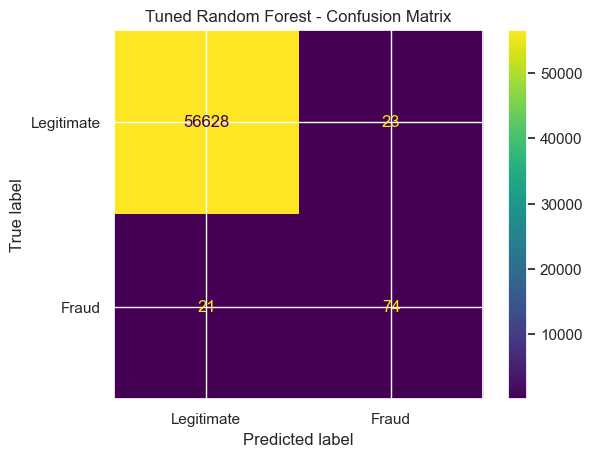

In [185]:
## Random Forest tuned SMote model achieved the best balance so far.

cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Legitimate', 'Fraud'])

#lets plot the image
disp.plot()
plt.title("Tuned Random Forest - Confusion Matrix")
plt.show()

### Summary

True Negative - 56628 (The number of non fraudulent transactions the model rightly predicted)

False Positive- 23 (The number of non-fraudulent transactions the model predicted as fraudulent)

True Positive- 74 (The number of fraudulent transaction the model predicted rightly i.e as fraudulent)

False Negative- 21 (The number of fraudulent transactions the model predicted as non fraudulent)

## Feature Importance

In [190]:
importance = pd.DataFrame({"Features": x.columns,"Importance": rf_tuned.named_steps['model'].feature_importances_})

In [191]:
#lets sort by importance 

importance = importance.sort_values(by="Importance", ascending=False)

importance.head(15)

,Features,Importance
14,V14,0.219095
10,V10,0.141414
12,V12,0.126850
17,V17,0.122233
11,V11,0.102059
4,V4,0.057456
3,V3,0.049592
16,V16,0.042704
7,V7,0.020971
9,V9,0.014778


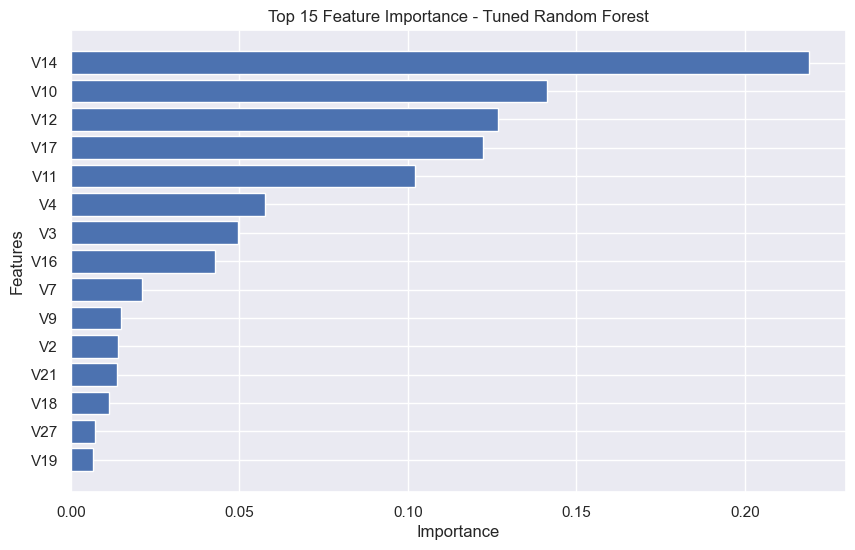

In [196]:
#lets save the features
top_features = importance.head(15)

#visualizing the features
plt.figure(figsize=(10, 6))
plt.barh(top_features['Features'], top_features['Importance'])
plt.gca().invert_yaxis()

plt.title('Top 15 Feature Importance - Tuned Random Forest')
plt.xlabel('Importance')
plt.ylabel('Features')

plt.show()

The feature importance analysis shows that V14 was the most influential feature in the Tuned Random Forest model, with an importance score of 0.219. V10, V12, V17 and V11 were the next most influential features. These variables are anonymized PCA-derived features in the dataset, so their individual real-world meanings cannot be directly interpreted. Nevertheless, their importance indicates that they contributed substantially to the model's ability to distinguish fraudulent from legitimate transactions.

## Conclusion

This project developed a supervised machine learning pipeline for detecting fraudulent credit card transactions in a highly imbalanced dataset. The dataset contained legitimate and fraudulent transactions, with fraudulent transactions representing a very small proportion of the observations.

Several classification algorithms were evaluated, including Logistic Regression, Random Forest and Gradient Boosting. SMOTE was implemented to address the class imbalance, after which hyperparameter tuning was performed on the SMOTE-based models.

The tuned Random Forest achieved the strongest overall performance, with a Precision of 0.76, Recall of 0.78, F1-Score of 0.77 and ROC-AUC of 0.980 on the test set. Its confusion matrix showed that it correctly identified 74 out of 95 fraudulent transactions while incorrectly classifying only 23 legitimate transactions as fraudulent.

Feature importance analysis showed that V14 was the most influential feature, followed by V10, V12, V17 and V11. Since the V1–V28 variables are anonymized PCA-derived features, their individual business meanings cannot be directly interpreted.

Overall, the Tuned Random Forest with SMOTE provided the best balance between identifying fraudulent transactions and minimizing false-positive alerts, making it the preferred model for this fraud detection task.